In [1]:
!pip install pandas matplotlib seaborn nltk textblob wordcloud plotly

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   --------------------------------- ------ 524.3/625.0 kB 1.0 MB/s eta 0:00:01
   ---------------------------------------- 625.0/625.0 kB 997.1 kB/s  0:00:00

   -------------------- ------------------- 1/2 [textblob]
   ---------------------------------------- 2/2 [textblob]



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from textblob import TextBlob
from wordcloud import WordCloud
import nltk
import re
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

print("✅ All libraries imported!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...


✅ All libraries imported!


In [3]:
# Load training and validation data
train_df = pd.read_csv("C:\\Users\\Administrator\\Downloads\\Code Alpha\\Data Analyst Intern\\twitter_training.csv", 
                        header=None,
                        names=["TweetID", "Topic", "Sentiment", "Tweet"])

val_df = pd.read_csv("C:\\Users\\Administrator\\Downloads\\Code Alpha\\Data Analyst Intern\\twitter_validation.csv",
                      header=None,
                      names=["TweetID", "Topic", "Sentiment", "Tweet"])

print(f"✅ Training data   : {len(train_df):,} tweets")
print(f"✅ Validation data : {len(val_df):,} tweets")
print()
print("Training Sample:")
train_df.head()

✅ Training data   : 74,682 tweets
✅ Validation data : 1,000 tweets

Training Sample:


,TweetID,Topic,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [4]:
def clean_tweet(text):
    if pd.isnull(text):
        return ""
    text = str(text).lower()                        # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)      # remove URLs
    text = re.sub(r'@\w+', '', text)                # remove @mentions
    text = re.sub(r'#\w+', '', text)                # remove hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)         # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()        # remove extra spaces
    text = ' '.join([w for w in text.split() 
                     if w not in STOPWORDS])         # remove stopwords
    return text

# Apply cleaning
train_df['Cleaned_Tweet'] = train_df['Tweet'].apply(clean_tweet)
val_df['Cleaned_Tweet'] = val_df['Tweet'].apply(clean_tweet)

# Remove rows with empty tweets
train_df = train_df[train_df['Cleaned_Tweet'].str.len() > 0]
val_df   = val_df[val_df['Cleaned_Tweet'].str.len() > 0]

print("✅ Data cleaned!")
print()
print("Before cleaning:", train_df['Tweet'].iloc[0])
print("After cleaning :", train_df['Cleaned_Tweet'].iloc[0])

✅ Data cleaned!

Before cleaning: im getting on borderlands and i will murder you all ,
After cleaning : im getting borderlands murder


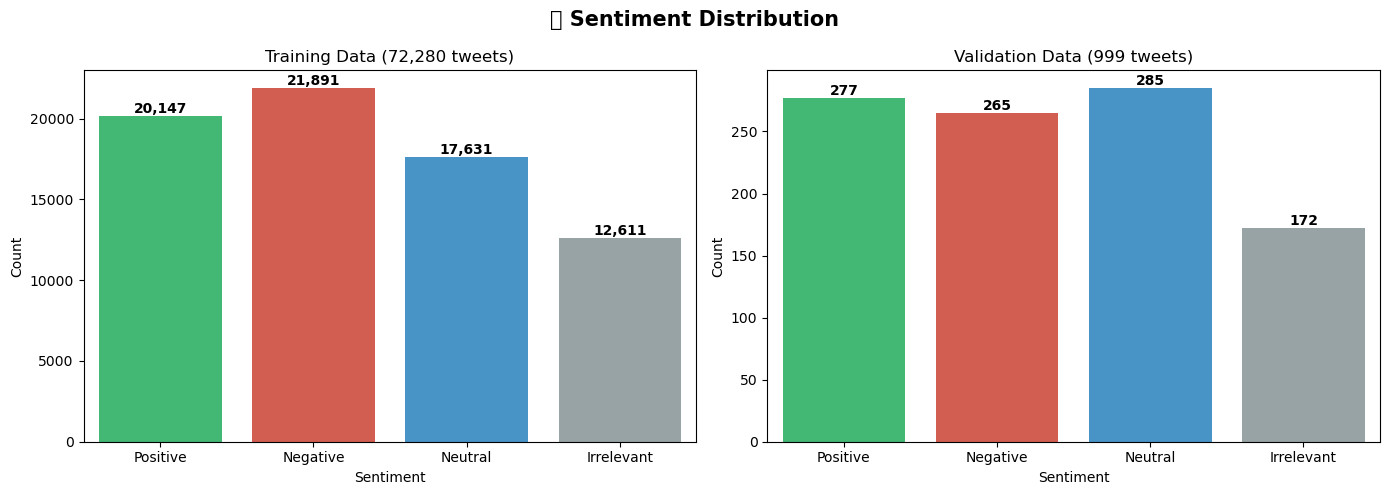

✅ Chart 1 saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("📊 Sentiment Distribution", fontsize=15, fontweight='bold')

colors = {
    'Positive'  : '#2ecc71',
    'Negative'  : '#e74c3c',
    'Neutral'   : '#3498db',
    'Irrelevant': '#95a5a6'
}

# Training data
order = ['Positive', 'Negative', 'Neutral', 'Irrelevant']
palette = [colors[s] for s in order]

sns.countplot(x='Sentiment', data=train_df, order=order,
              palette=palette, ax=axes[0])
axes[0].set_title(f"Training Data ({len(train_df):,} tweets)")
axes[0].set_ylabel("Count")
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

# Validation data
sns.countplot(x='Sentiment', data=val_df, order=order,
              palette=palette, ax=axes[1])
axes[1].set_title(f"Validation Data ({len(val_df):,} tweets)")
axes[1].set_ylabel("Count")
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("chart1_sentiment_distribution.png", dpi=150)
plt.show()
print("✅ Chart 1 saved!")

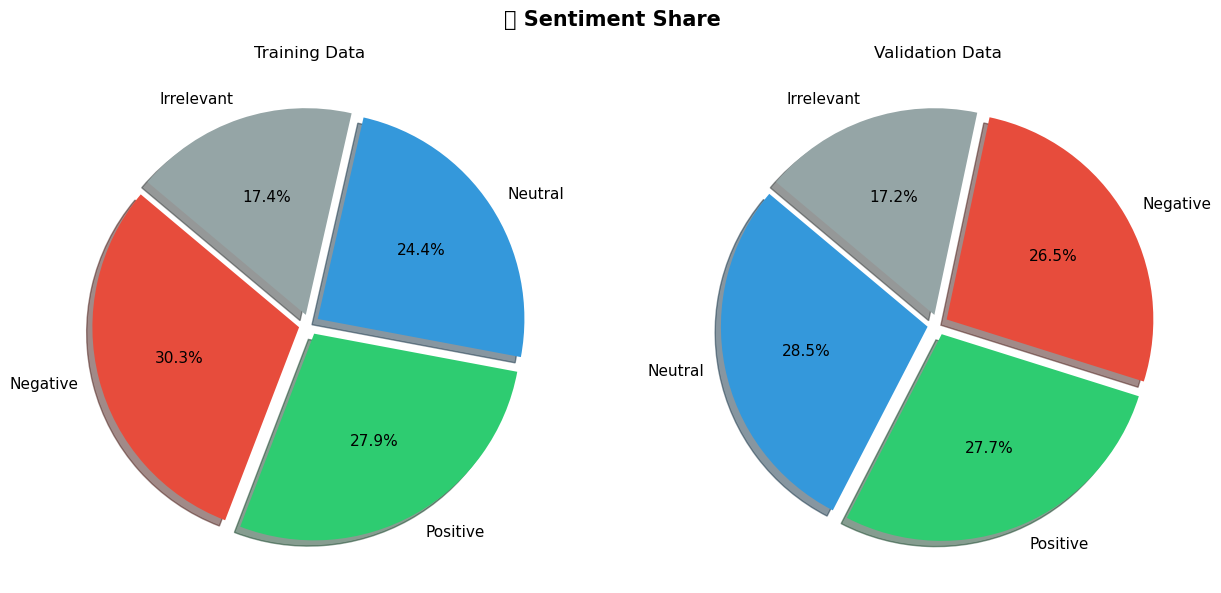

✅ Chart 2 saved!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("🥧 Sentiment Share", fontsize=15, fontweight='bold')

for ax, df, title in zip(axes,
                          [train_df, val_df],
                          ['Training Data', 'Validation Data']):
    counts = df['Sentiment'].value_counts()
    clrs   = [colors[s] for s in counts.index]
    ax.pie(counts, labels=counts.index, colors=clrs,
           autopct='%1.1f%%', startangle=140,
           explode=[0.05]*len(counts), shadow=True,
           textprops={'fontsize': 11})
    ax.set_title(title)

plt.tight_layout()
plt.savefig("chart2_sentiment_pie.png", dpi=150)
plt.show()
print("✅ Chart 2 saved!")

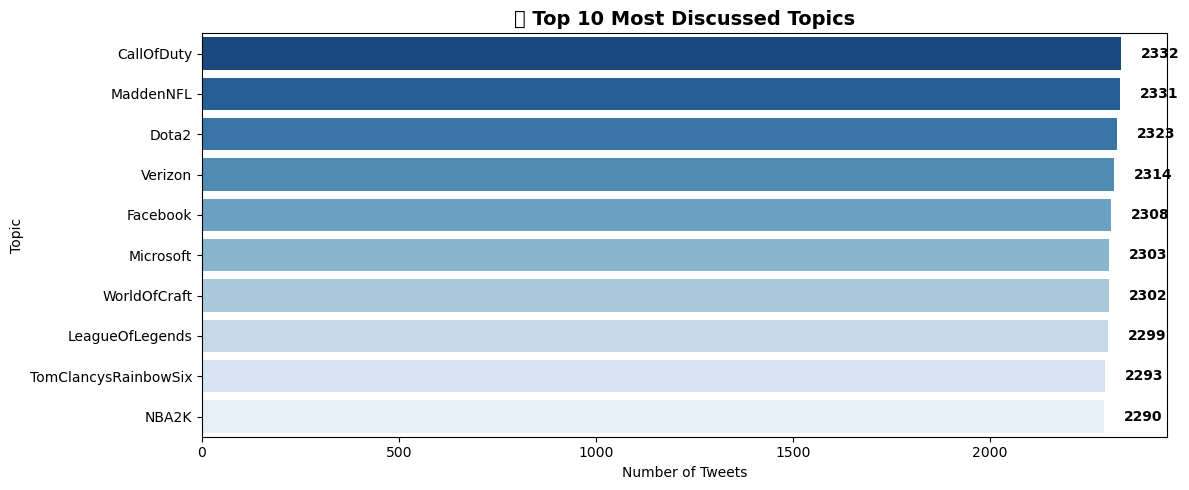

✅ Chart 3 saved!


In [7]:
plt.figure(figsize=(12, 5))

top_topics = train_df['Topic'].value_counts().head(10)
sns.barplot(x=top_topics.values, y=top_topics.index, palette='Blues_r')

plt.title("🏷️ Top 10 Most Discussed Topics", fontsize=14, fontweight='bold')
plt.xlabel("Number of Tweets")
plt.ylabel("Topic")
for i, v in enumerate(top_topics.values):
    plt.text(v + 50, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("chart3_top_topics.png", dpi=150)
plt.show()
print("✅ Chart 3 saved!")

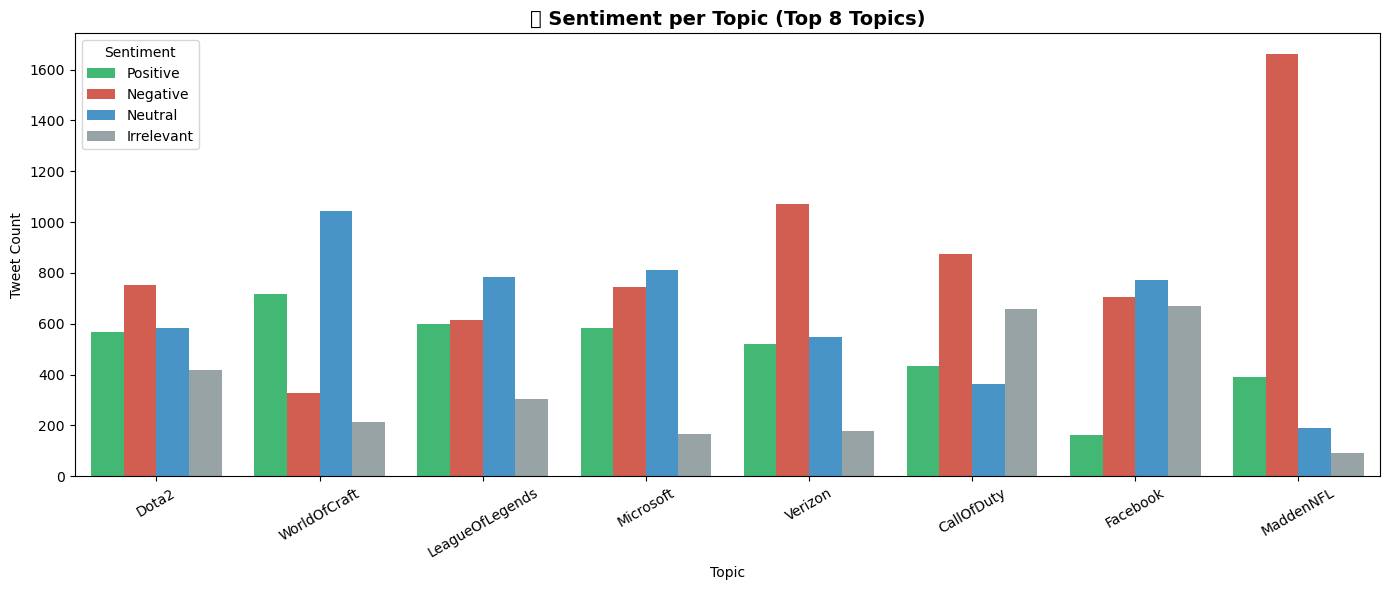

✅ Chart 4 saved!


In [8]:
top8_topics = train_df['Topic'].value_counts().head(8).index
df_top8     = train_df[train_df['Topic'].isin(top8_topics)]

plt.figure(figsize=(14, 6))
sns.countplot(data=df_top8, x='Topic', hue='Sentiment',
              hue_order=order,
              palette=[colors[s] for s in order])

plt.title("📌 Sentiment per Topic (Top 8 Topics)", fontsize=14, fontweight='bold')
plt.xlabel("Topic")
plt.ylabel("Tweet Count")
plt.xticks(rotation=30)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.savefig("chart4_topic_sentiment.png", dpi=150)
plt.show()
print("✅ Chart 4 saved!")

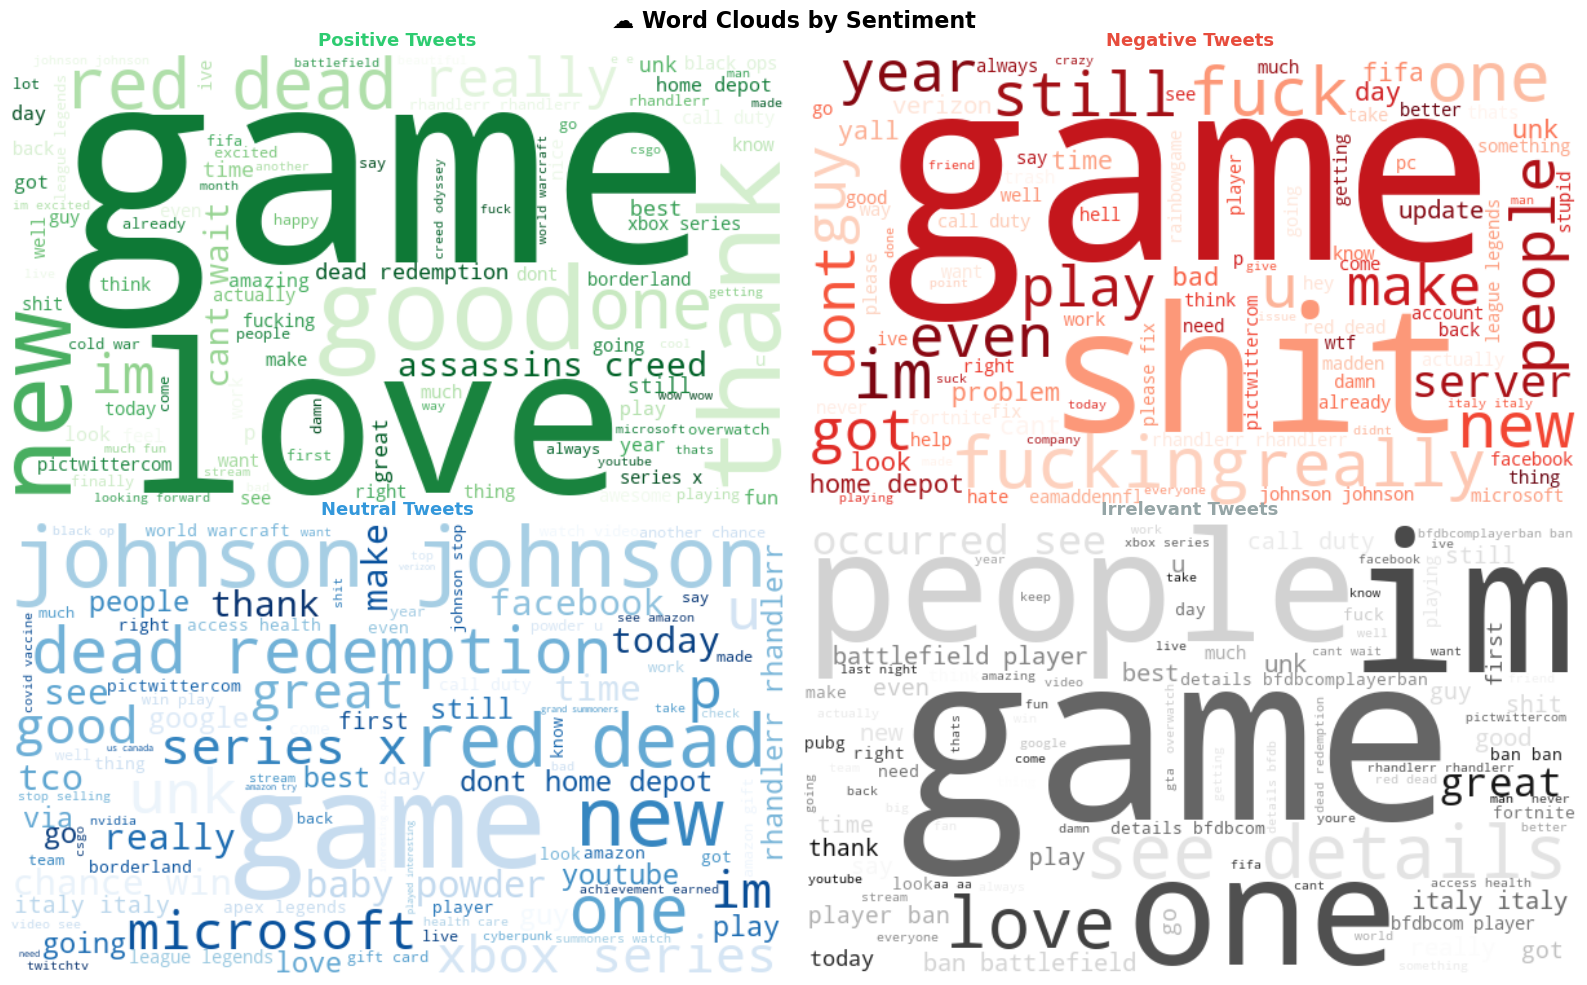

✅ Chart 5 saved!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("☁️ Word Clouds by Sentiment", fontsize=16, fontweight='bold')

sentiments  = ['Positive', 'Negative', 'Neutral', 'Irrelevant']
wc_colors   = ['Greens', 'Reds', 'Blues', 'Greys']

for ax, sentiment, cmap in zip(axes.flatten(), sentiments, wc_colors):
    text = ' '.join(
        train_df[train_df['Sentiment'] == sentiment]['Cleaned_Tweet']
    )
    wordcloud = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=cmap,
        max_words=100
    ).generate(text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"{sentiment} Tweets", fontsize=13, fontweight='bold',
                 color=list(colors.values())[sentiments.index(sentiment)])

plt.tight_layout()
plt.savefig("chart5_wordclouds.png", dpi=150)
plt.show()
print("✅ Chart 5 saved!")

In [11]:
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

# Apply on validation data (smaller = faster)
val_df['Polarity']     = val_df['Cleaned_Tweet'].apply(get_polarity)
val_df['Subjectivity'] = val_df['Cleaned_Tweet'].apply(get_subjectivity)

def polarity_to_label(score):
    if score > 0.05:  return 'Positive'
    elif score < -0.05: return 'Negative'
    else: return 'Neutral'

val_df['Predicted_Sentiment'] = val_df['Polarity'].apply(polarity_to_label)

print("✅ TextBlob scoring done!")
print()
print("Sample results:")
val_df[['Tweet', 'Sentiment', 'Predicted_Sentiment', 
        'Polarity', 'Subjectivity']].head(10)

✅ TextBlob scoring done!

Sample results:


,Tweet,Sentiment,Predicted_Sentiment,Polarity,Subjectivity
0,I mentioned on Facebook that I was struggling ...,Irrelevant,Negative,-0.150000,0.916667
1,BBC News - Amazon boss Jeff Bezos rejects clai...,Neutral,Neutral,0.000000,0.000000
2,@Microsoft Why do I pay for WORD when it funct...,Negative,Negative,-0.400000,0.600000
3,"CSGO matchmaking is so full of closet hacking,...",Negative,Negative,-0.350000,0.650000
4,Now the President is slapping Americans in the...,Neutral,Positive,0.200000,0.200000
5,Hi @EAHelp I’ve had Madeleine McCann in my cel...,Negative,Negative,-0.218750,0.375000
6,Thank you @EAMaddenNFL!! \n\nNew TE Austin Hoo...,Positive,Positive,0.136364,0.454545
7,"Rocket League, Sea of Thieves or Rainbow Six: ...",Positive,Positive,0.750000,0.450000
8,my ass still knee-deep in Assassins Creed Odys...,Positive,Positive,0.600000,1.000000
9,FIX IT JESUS ! Please FIX IT ! What In the wor...,Negative,Negative,-0.300000,0.400000
